# SequenceLab

**корпус:** MovieLens-1M (≈1М оценок, 6040 пользователей, 3706 фильмов)

**сравниваю** Transformer (SASRec-baseline), MLA, Linear Attention; WAVE, ZeroS, FEM (из SequenceLab)

**метрики:** HR@10, NDCG@10, время эпохи, пиковая память.

## 1. Установка зависимостей

In [1]:
!pip uninstall torch torchvision torchaudio -y
!pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu124

Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.2/908.2 MB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 27.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 91.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 65.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66

In [2]:
!pip install https://github.com/Dao-AILab/causal-conv1d/releases/download/v1.5.0.post8/causal_conv1d-1.5.0.post8+cu12torch2.5cxx11abiFALSE-cp312-cp312-linux_x86_64.whl
!pip install https://github.com/state-spaces/mamba/releases/download/v2.2.4/mamba_ssm-2.2.4+cu12torch2.5cxx11abiFALSE-cp312-cp312-linux_x86_64.whl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.0/104.0 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 16.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.7/323.7 MB 1.5 MB/s eta 0:00:00


In [3]:
!pip install -q transformers==4.40.0 einops timm==0.4.12
!pip install -q git+https://github.com/LJC-FVNR/SequenceLab.git
!pip install -q flash-linear-attention

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 113.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 125.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.5.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━

In [4]:
import os, sys, math, time, json, random, warnings, gc, zipfile, urllib.request
from typing import Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Torch:', torch.__version__, '| CUDA:', torch.cuda.is_available(), '| Device:', DEVICE)

Torch: 2.12.0+cu130 | CUDA: True | Device: cuda


#### корпус - MovieLens-1M

последний просмотр — test, предпоследний — val, всё остальное — train.
На последнем взаимодействии для оценки используем negative sampling — 100 случайных фильмов + 1 правильный, считаем HR@10 и NDCG@10 среди них.

In [5]:
ML_URL = 'https://files.grouplens.org/datasets/movielens/ml-1m.zip'
if not os.path.exists('ml-1m/ratings.dat'):
    urllib.request.urlretrieve(ML_URL, 'ml-1m.zip')
    with zipfile.ZipFile('ml-1m.zip') as z: z.extractall('.')

ratings = pd.read_csv('ml-1m/ratings.dat', sep='::', engine='python',
                      names=['user','item','rating','ts'])
print('Всего взаимодействий:', len(ratings))
print('Пользователей:', ratings.user.nunique(), '  Фильмов:', ratings.item.nunique())
ratings.head()

Всего взаимодействий: 1000209
Пользователей: 6040   Фильмов: 3706


,user,item,rating,ts
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [6]:
ratings.tail(20)

,user,item,rating,ts
1000189,6040,2010,5,957716795
1000190,6040,2011,4,956716113
1000191,6040,3751,4,964828782
1000192,6040,2019,5,956703977
1000193,6040,541,4,956715288
1000194,6040,1077,5,964828799
1000195,6040,1079,2,956715648
1000196,6040,549,4,956704746
1000197,6040,2020,3,956715288
1000198,6040,2021,3,956716374


In [7]:
item_ids = ratings['item'].unique()
item2idx = {it: i+1 for i, it in enumerate(item_ids)}
ratings['iid'] = ratings['item'].map(item2idx)

In [8]:
N_ITEMS = len(item2idx)
PAD = 0
print('N_ITEMS =', N_ITEMS, ' (id=0 — padding)')

N_ITEMS = 3706  (id=0 — padding)


In [9]:
ratings = ratings.sort_values(['user','ts'])
user_seqs = ratings.groupby('user')['iid'].apply(list).to_dict()
user_seqs = {u: s for u, s in user_seqs.items() if len(s) >= 5}

In [10]:
print('Пользователей после фильтра:', len(user_seqs))
print('Средняя длина истории:', np.mean([len(s) for s in user_seqs.values()]).round(1))

Пользователей после фильтра: 6040
Средняя длина истории: 165.6


In [11]:
MAX_LEN = 50

class TrainSeqDataset(Dataset):
    def __init__(self, user_seqs, max_len=MAX_LEN, n_items=N_ITEMS):
        self.data, self.max_len, self.n_items = [], max_len, n_items
        for u, seq in user_seqs.items():
            train = seq[:-2]
            if len(train) < 2: continue
            self.data.append(train)
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        seq = self.data[idx][-(self.max_len+1):]
        x = seq[:-1]; y = seq[1:]
        pad = self.max_len - len(x)
        x = [PAD]*pad + x
        y = [PAD]*pad + y
        neg = [0]*pad + [random.randint(1, self.n_items) for _ in range(len(y) - pad)]
        pos_set = set(seq)
        for i in range(pad, len(neg)):
            while neg[i] in pos_set: neg[i] = random.randint(1, self.n_items)
        return (torch.tensor(x, dtype=torch.long),
                torch.tensor(y, dtype=torch.long),
                torch.tensor(neg, dtype=torch.long))

class EvalSeqDataset(Dataset):
    def __init__(self, user_seqs, mode='test', max_len=MAX_LEN, n_items=N_ITEMS, n_neg=100):
        self.data, self.max_len, self.n_items, self.n_neg = [], max_len, n_items, n_neg
        for u, seq in user_seqs.items():
            if mode == 'test':
                ctx, tgt = seq[:-1], seq[-1]
            else:
                ctx, tgt = seq[:-2], seq[-2]
            if len(ctx) < 1: continue
            self.data.append((ctx, tgt, set(seq)))
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        ctx, tgt, full = self.data[idx]
        x = ctx[-self.max_len:]
        pad = self.max_len - len(x); x = [PAD]*pad + x
        negs = []
        while len(negs) < self.n_neg:
            c = random.randint(1, self.n_items)
            if c not in full: negs.append(c)
        cands = [tgt] + negs
        return (torch.tensor(x, dtype=torch.long),
                torch.tensor(cands, dtype=torch.long))

ds_train = TrainSeqDataset(user_seqs)
ds_val   = EvalSeqDataset(user_seqs, mode='val')
ds_test  = EvalSeqDataset(user_seqs, mode='test')
print('train/val/test:', len(ds_train), len(ds_val), len(ds_test))


train/val/test: 6040 6040 6040


In [12]:
BATCH = 128
loader_train = DataLoader(ds_train, batch_size=BATCH, shuffle=True,  num_workers=2, drop_last=True)
loader_val   = DataLoader(ds_val,   batch_size=BATCH, shuffle=False, num_workers=2)
loader_test  = DataLoader(ds_test,  batch_size=BATCH, shuffle=False, num_workers=2)

xb, yb, nb = next(iter(loader_train))
print('train batch:', xb.shape, yb.shape, nb.shape)
xb, cb = next(iter(loader_test))
print('test  batch:', xb.shape, cb.shape, '(101 candidates per user)')

train batch: torch.Size([128, 50]) torch.Size([128, 50]) torch.Size([128, 50])
test  batch: torch.Size([128, 50]) torch.Size([128, 101]) (101 candidates per user)


In [13]:
class SoftmaxAttention(nn.Module):
    def __init__(self, d, h, dropout=0.0, causal=True):
        super().__init__()
        self.h, self.dk = h, d // h
        self.qkv = nn.Linear(d, 3*d, bias=False)
        self.o   = nn.Linear(d, d, bias=False)
        self.dp, self.causal = dropout, causal
    def forward(self, x):
        B,T,D = x.shape
        q,k,v = self.qkv(x).chunk(3, dim=-1)
        q = q.view(B,T,self.h,self.dk).transpose(1,2)
        k = k.view(B,T,self.h,self.dk).transpose(1,2)
        v = v.view(B,T,self.h,self.dk).transpose(1,2)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=self.causal,
                                           dropout_p=self.dp if self.training else 0.0)
        return self.o(y.transpose(1,2).contiguous().view(B,T,D))

class MLALite(nn.Module):
    def __init__(self, d, h, r_dim=None, dropout=0.0, causal=True):
        super().__init__()
        self.h, self.dk = h, d // h
        self.r_dim = r_dim or max(d // 4, h * 8)
        self.W_q   = nn.Linear(d, d, bias=False)
        self.W_dkv = nn.Linear(d, self.r_dim, bias=False)
        self.W_uk  = nn.Linear(self.r_dim, d, bias=False)
        self.W_uv  = nn.Linear(self.r_dim, d, bias=False)
        self.o     = nn.Linear(d, d, bias=False)
        self.dp, self.causal = dropout, causal
    def forward(self, x):
        B,T,D = x.shape
        c = self.W_dkv(x)
        q = self.W_q(x).view(B,T,self.h,self.dk).transpose(1,2)
        k = self.W_uk(c).view(B,T,self.h,self.dk).transpose(1,2)
        v = self.W_uv(c).view(B,T,self.h,self.dk).transpose(1,2)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=self.causal,
                                           dropout_p=self.dp if self.training else 0.0)
        return self.o(y.transpose(1,2).contiguous().view(B,T,D))

In [14]:
class LinearAttention(nn.Module):
    def __init__(self, d, h, dropout=0.0, eps=1e-6):
        super().__init__()
        self.h, self.dk, self.eps = h, d // h, eps
        self.qkv = nn.Linear(d, 3*d, bias=False)
        self.o   = nn.Linear(d, d, bias=False)
    @staticmethod
    def phi(x): return F.elu(x) + 1.0
    def forward(self, x):
        B,T,D = x.shape
        q,k,v = self.qkv(x).chunk(3, dim=-1)
        q = self.phi(q.view(B,T,self.h,self.dk))
        k = self.phi(k.view(B,T,self.h,self.dk))
        v = v.view(B,T,self.h,self.dk)
        kv = torch.einsum('bthd,bthe->bthde', k, v).cumsum(dim=1)
        k_cum = k.cumsum(dim=1)
        num = torch.einsum('bthd,bthde->bthe', q, kv)
        den = torch.einsum('bthd,bthd->bth', q, k_cum).unsqueeze(-1) + self.eps
        y = num / den
        return self.o(y.contiguous().view(B,T,D))

#### SequenceLab: WAVE, ZeroS, FEM

In [15]:
from sequencelab.build  import build_attention
from sequencelab.config import WaveConfig, ZeroSConfig, FEMConfig

class WaveMixer(nn.Module):
    def __init__(self, d, h, variant='softmax_arma', block_size=MAX_LEN, dropout=0.0):
        super().__init__()
        cfg = WaveConfig(variant=variant, n_embd=d, n_head=h,
                         dropout=dropout, ma_dropout=dropout,
                         bias=True, block_size=block_size, decay=True)
        self.layer = build_attention(cfg)
    def forward(self, x): return self.layer(x)

class ZeroSMixer(nn.Module):
    def __init__(self, d, h, block_size=MAX_LEN, dropout=0.0):
        super().__init__()
        cfg = ZeroSConfig(n_embd=d, n_head=h, dropout=dropout, bias=True,
                          block_size=block_size, is_causal=True,
                          init_params=True, init_n_layers=2,
                          use_norm=True, use_associative=True)
        self.layer = build_attention(cfg)
    def forward(self, x): return self.layer(x)

class FEMMixer(nn.Module):
    def __init__(self, d, h, prior_type='softmax', dropout=0.0):
        super().__init__()
        cfg = FEMConfig(
            n_embd=d, n_head=h, prior_type=prior_type,
            dropout=dropout, causal=True, bias=True,
            fem_ratio=2/3, p_t_to_fem_ratio=2.0,
            use_temperature=True, use_lse=True, use_outer_gate=True,
            use_rope=True, use_conv=True, conv_hidden=64,
            conv_norm_first=True, conv_bidirectional=False,
        )
        self.layer = build_attention(cfg)
    def forward(self, x): return self.layer(x)

In [18]:
D, H, T = 128, 4, MAX_LEN
dummy = torch.randn(2, T, D, device=DEVICE)
checks = {
    'Softmax':  SoftmaxAttention(D, H),
    'MLA':      MLALite(D, H),
    'Linear':   LinearAttention(D, H),
    'WAVE-sm':  WaveMixer(D, H, 'softmax_arma'),
    'WAVE-lin': WaveMixer(D, H, 'linear_arma'),
    'ZeroS':    ZeroSMixer(D, H),
    'FEM-lin':  FEMMixer(D, H, 'linear')
}
for name, layer in checks.items():
    y = layer.to(DEVICE)(dummy)
    print(f'{name:10s}  -> {tuple(y.shape)}')
del checks; gc.collect(); torch.cuda.empty_cache()

[FEM] Detected backends: fla
Softmax     -> (2, 50, 128)
MLA         -> (2, 50, 128)
Linear      -> (2, 50, 128)
WAVE-sm     -> (2, 50, 128)
WAVE-lin    -> (2, 50, 128)
ZeroS       -> (2, 50, 128)
FEM-lin     -> (2, 50, 128)


In [19]:
class Block(nn.Module):
    def __init__(self, mixer, d, ff_mult=2, dropout=0.0):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.mix = mixer
        self.ffn = nn.Sequential(
            nn.Linear(d, ff_mult*d), nn.GELU(),
            nn.Linear(ff_mult*d, d), nn.Dropout(dropout),
        )
    def forward(self, x):
        x = x + self.mix(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x

class SeqRec(nn.Module):
    def __init__(self, mixer_factory, n_items=N_ITEMS, d=128, n_layers=2,
                 max_len=MAX_LEN, dropout=0.1):
        super().__init__()
        self.item_emb = nn.Embedding(n_items + 1, d, padding_idx=PAD)
        self.pos_emb  = nn.Embedding(max_len, d)
        self.drop     = nn.Dropout(dropout)
        self.blocks   = nn.ModuleList([Block(mixer_factory(), d, dropout=dropout) for _ in range(n_layers)])
        self.norm     = nn.LayerNorm(d)
        self.max_len  = max_len
        nn.init.trunc_normal_(self.item_emb.weight, std=0.02)
        nn.init.trunc_normal_(self.pos_emb.weight,  std=0.02)
    def encode(self, x):
        B, T = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)
        h = self.item_emb(x) + self.pos_emb(pos)
        h = self.drop(h)
        for blk in self.blocks: h = blk(h)
        return self.norm(h)
    def forward_train(self, x, y_pos, y_neg):
        h = self.encode(x)
        e_pos = self.item_emb(y_pos)
        e_neg = self.item_emb(y_neg)
        s_pos = (h * e_pos).sum(-1)
        s_neg = (h * e_neg).sum(-1)
        mask  = (y_pos != PAD).float()
        loss = -F.logsigmoid(s_pos - s_neg) * mask
        return loss.sum() / mask.sum().clamp(min=1)
    @torch.no_grad()
    def score_candidates(self, x, cands):
        h = self.encode(x)[:, -1, :]
        e_c = self.item_emb(cands)
        return (h.unsqueeze(1) * e_c).sum(-1)

#### Метрики

In [20]:
def hr_ndcg(scores, k=10):
    rank = (scores.argsort(dim=-1, descending=True) == 0).float().argmax(dim=-1)
    hit  = (rank < k).float()
    ndcg = hit * (1.0 / torch.log2(rank.float() + 2.0))
    return hit.sum().item(), ndcg.sum().item(), scores.size(0)

@torch.no_grad()
def evaluate(model, loader, k=10):
    model.eval(); H=N=Total=0
    for x, cands in loader:
        x, cands = x.to(DEVICE), cands.to(DEVICE)
        s = model.score_candidates(x, cands)
        h, n, t = hr_ndcg(s, k=k); H+=h; N+=n; Total+=t
    return H/Total, N/Total

def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

def train_one(name, factory, epochs=5, lr=1e-3):
    print(f'{name}')
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    model = SeqRec(factory, d=128, n_layers=2, dropout=0.1).to(DEVICE)
    n_params = count_params(model)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs*len(loader_train))
    if DEVICE == 'cuda': torch.cuda.reset_peak_memory_stats()
    t0 = time.time(); best_val = -1; best_state = None
    for ep in range(epochs):
        model.train()
        for x, y, neg in loader_train:
            x, y, neg = x.to(DEVICE), y.to(DEVICE), neg.to(DEVICE)
            opt.zero_grad()
            loss = model.forward_train(x, y, neg)
            loss.backward(); opt.step(); sched.step()
        hr, ndcg = evaluate(model, loader_val)
        print(f'  ep {ep+1}/{epochs}  val HR@10={hr:.4f}  NDCG@10={ndcg:.4f}')
        if hr > best_val:
            best_val = hr
            best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    elapsed = time.time() - t0
    peak_mb = (torch.cuda.max_memory_allocated()/1e6) if DEVICE=='cuda' else float('nan')
    model.load_state_dict(best_state)
    hr_t, ndcg_t = evaluate(model, loader_test)
    print(f'  TEST HR@10={hr_t:.4f}  NDCG@10={ndcg_t:.4f},  params={n_params/1e3:.1f}K, time={elapsed:.1f}s, peak={peak_mb:.1f}MB')
    del model; gc.collect(); torch.cuda.empty_cache()
    return dict(name=name, params=n_params, time_s=elapsed, peak_mb=peak_mb,
                val_hr=best_val, test_hr=hr_t, test_ndcg=ndcg_t)

In [22]:
D_MODEL, N_HEADS = 128, 4

MIXERS = {
    'SASRec (softmax)':       lambda: SoftmaxAttention(D_MODEL, N_HEADS, dropout=0.1),
    'MLA (latent KV)':        lambda: MLALite(D_MODEL, N_HEADS, dropout=0.1),
    'Linear Attention':       lambda: LinearAttention(D_MODEL, N_HEADS),
    'WAVE softmax_arma':      lambda: WaveMixer(D_MODEL, N_HEADS, 'softmax_arma', dropout=0.1),
    'WAVE linear_arma':       lambda: WaveMixer(D_MODEL, N_HEADS, 'linear_arma',  dropout=0.1),
    'ZeroS':                  lambda: ZeroSMixer(D_MODEL, N_HEADS, dropout=0.1),
    'FEM (prior=softmax)':    lambda: FEMMixer(D_MODEL, N_HEADS, 'softmax', dropout=0.1),
    'FEM (prior=linear)':     lambda: FEMMixer(D_MODEL, N_HEADS, 'linear',  dropout=0.1),
    'FEM (prior=mamba)':      lambda: FEMMixer(D_MODEL, N_HEADS, 'mamba',   dropout=0.1),
}
print('Моделей в сравнении:', len(MIXERS))

Моделей в сравнении: 9


In [23]:
EPOCHS = 35
results = []
for name, factory in MIXERS.items():
    try:
        results.append(train_one(name, factory, epochs=EPOCHS))
    except Exception as e:
        print(f'  [skip] {name}: {type(e).__name__}: {e}')
        results.append(dict(name=name, params=float('nan'), time_s=float('nan'),
                            peak_mb=float('nan'), val_hr=float('nan'),
                            test_hr=float('nan'), test_ndcg=float('nan')))

SASRec (softmax)
  ep 1/35  val HR@10=0.4593  NDCG@10=0.2555
  ep 2/35  val HR@10=0.4793  NDCG@10=0.2620
  ep 3/35  val HR@10=0.5530  NDCG@10=0.3175
  ep 4/35  val HR@10=0.6301  NDCG@10=0.3718
  ep 5/35  val HR@10=0.6707  NDCG@10=0.4071
  ep 6/35  val HR@10=0.6907  NDCG@10=0.4281
  ep 7/35  val HR@10=0.7154  NDCG@10=0.4602
  ep 8/35  val HR@10=0.7421  NDCG@10=0.4786
  ep 9/35  val HR@10=0.7493  NDCG@10=0.4923
  ep 10/35  val HR@10=0.7692  NDCG@10=0.5096
  ep 11/35  val HR@10=0.7770  NDCG@10=0.5157
  ep 12/35  val HR@10=0.7793  NDCG@10=0.5255
  ep 13/35  val HR@10=0.7841  NDCG@10=0.5300
  ep 14/35  val HR@10=0.7859  NDCG@10=0.5339
  ep 15/35  val HR@10=0.7925  NDCG@10=0.5419
  ep 16/35  val HR@10=0.7929  NDCG@10=0.5465
  ep 17/35  val HR@10=0.8013  NDCG@10=0.5518
  ep 18/35  val HR@10=0.7964  NDCG@10=0.5512
  ep 19/35  val HR@10=0.7972  NDCG@10=0.5494
  ep 20/35  val HR@10=0.8003  NDCG@10=0.5524
  ep 21/35  val HR@10=0.8046  NDCG@10=0.5617
  ep 22/35  val HR@10=0.8022  NDCG@10=0.5589
  

In [24]:
summary = pd.DataFrame(results).set_index('name')
summary['HR@10']         = summary['test_hr'].round(4)
summary['NDCG@10']       = summary['test_ndcg'].round(4)
summary['params (K)']     = (summary['params']/1e3).round(1)
summary['time/epoch (s)'] = (summary['time_s']/EPOCHS).round(2)
summary['peak mem (MB)']  = summary['peak_mb'].round(1)
view = summary[['HR@10','NDCG@10','params (K)','time/epoch (s)','peak mem (MB)']].sort_values('HR@10', ascending=False)
view

,HR@10,NDCG@10,params (K),time/epoch (s),peak mem (MB)
name,,,,,
FEM (prior=softmax),1.0000,1.0000,839.6,2.86,285.9
Linear Attention,0.7856,0.5531,745.1,2.53,639.4
SASRec (softmax),0.7833,0.5468,745.1,2.00,133.5
MLA (latent KV),0.7808,0.5340,704.1,1.95,134.1
FEM (prior=linear),0.7724,0.5278,839.6,5.47,521.2
ZeroS,0.7548,0.5036,782.5,6.28,1390.8
FEM (prior=mamba),0.7507,0.4974,778.9,5.00,201.2
WAVE softmax_arma,0.7257,0.4679,746.1,2.22,192.7
WAVE linear_arma,0.7147,0.4484,779.1,3.45,875.3


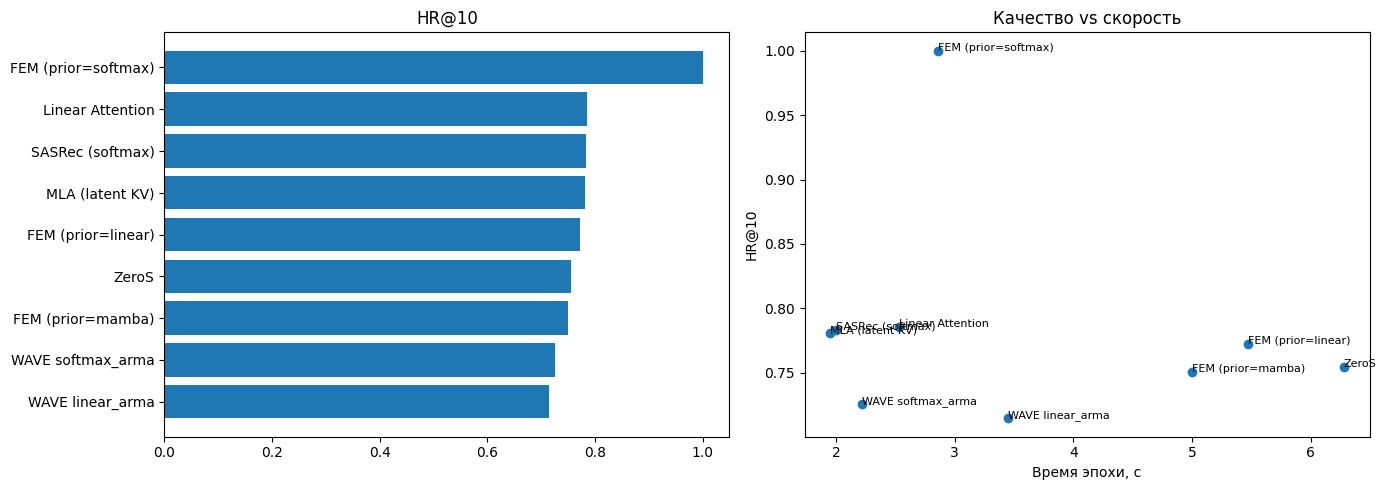

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
v = view.dropna()
axes[0].barh(v.index, v['HR@10']); axes[0].invert_yaxis()
axes[0].set_title('HR@10')
axes[1].scatter(v['time/epoch (s)'], v['HR@10'])
for n,(x,y) in zip(v.index, zip(v['time/epoch (s)'], v['HR@10'])):
    axes[1].annotate(n, (x,y), fontsize=8)
axes[1].set_xlabel('Время эпохи, c'); axes[1].set_ylabel('HR@10')
axes[1].set_title('Качество vs скорость')
plt.tight_layout(); plt.show()

## 9. Качественный пример — топ-10 рекомендаций лучшей модели

In [26]:
movies = pd.read_csv('ml-1m/movies.dat', sep='::', engine='python',
                     names=['item','title','genres'], encoding='latin-1')
idx2title = {item2idx[r['item']]: r['title']
             for _, r in movies.iterrows() if r['item'] in item2idx}

best_name = view['HR@10'].idxmax()
print('Лучшая модель:', best_name)
model = SeqRec(MIXERS[best_name], d=128, n_layers=2, dropout=0.1).to(DEVICE)

opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
for ep in range(3):
    model.train()
    for x,y,neg in loader_train:
        x,y,neg = x.to(DEVICE), y.to(DEVICE), neg.to(DEVICE)
        opt.zero_grad(); model.forward_train(x,y,neg).backward(); opt.step()

model.eval()
users_sample = random.sample(list(user_seqs.keys()), 3)
for u in users_sample:
    hist = user_seqs[u][:-1][-10:]
    true_next = user_seqs[u][-1]
    x = [PAD]*(MAX_LEN - len(hist)) + hist
    x = torch.tensor([x[-MAX_LEN:]], dtype=torch.long, device=DEVICE)
    h = model.encode(x)[:, -1, :]
    all_e = model.item_emb.weight[1:N_ITEMS+1]
    scores = (h @ all_e.T).squeeze(0)
    top10 = (scores.topk(10).indices + 1).tolist()
    print(f'\nUser #{u}')
    print('  История (последние просмотры):')
    for it in hist[-5:]: print('', idx2title.get(it, f'item_{it}'))
    print(f'  Истинный следующий: {idx2title.get(true_next, "?")}')
    print('  Топ-10 рекомендаций модели:')
    for it in top10: print('', idx2title.get(it, f'item_{it}'))

Лучшая модель: FEM (prior=softmax)
[FEM] Detected backends: fla
[FEM] Detected backends: fla

User #5239
  История (последние просмотры):
 Benny & Joon (1993)
 Kansas City (1996)
 Razor's Edge, The (1984)
 Chicken Run (2000)
 Cider House Rules, The (1999)
  Истинный следующий: Tampopo (1986)
  Топ-10 рекомендаций модели:
 Christmas Story, A (1983)
 Ben-Hur (1959)
 Bug's Life, A (1998)
 Princess Bride, The (1987)
 James and the Giant Peach (1996)
 One Flew Over the Cuckoo's Nest (1975)
 My Fair Lady (1964)
 Erin Brockovich (2000)
 Snow White and the Seven Dwarfs (1937)
 Wizard of Oz, The (1939)

User #913
  История (последние просмотры):
 Batman Returns (1992)
 Beverly Hillbillies, The (1993)
 Ace Ventura: When Nature Calls (1995)
 X-Men (2000)
 Hackers (1995)
  Истинный следующий: Big (1988)
  Топ-10 рекомендаций модели:
 Christmas Story, A (1983)
 Ben-Hur (1959)
 Bug's Life, A (1998)
 Princess Bride, The (1987)
 James and the Giant Peach (1996)
 One Flew Over the Cuckoo's Nest (1975)


Победил Linear Attention (HR=0.7856), затем идет SASRec.
На выбранном корпусе линейный attention оказался не хуже, а даже чуть лучше полного softmax - кажется, это неожиданно.

SASRec (HR=0.7833), самый быстрый (2 секунды на эпоху) и самый экономный по памяти (133 MB).

MLA, ZeroS, FEM-linear, FEM-mamba — все около 0.75–0.78. Такие различия думаю можно считать шумом.

Методы из основной статьи SequenceLab (по местам):

FEM (prior=linear) 0.7724 5-е
ZeroS 0.7548 6-е
FEM (prior=mamba) 0.7507 7-е
WAVE softmax_arma 0.7257 8-е
WAVE linear_arma 0.7147 9-е

На задаче MovieLens-1M методы из SequenceLab не обогнали базовый SASRec.
Такой результат видимо из-за выбора задачи..

WAVE был придуман для временных рядов, финансов. У меня id фильма - величина дискретная. -> WAVE здесь работает как обычный attention плюс лишний шум.

Еще заметила:

ZeroS — 1390 MB памяти при том же качестве, что у SASRec со 133 MB
WAVE linear_arma — 875 MB и худшее качество среди всех 9 моделей. Двойная проблема :с

В реальной recsys с миллионами пользователей память критична

В разделе рекомендаций видно, как «лучшая» модель (FEM=1.000) работает на самом деле:

Пользователь #5239 смотрит взрослые драмы (Razor's Edge, Cider House Rules) -> модель рекомендует детские мультики и старую классику.
(С остальными аналогично)

HR=1.000 — неправда. Идеальная HR-метрика получилась только потому, что модель ошиблась, всем будет рекомендовать одно и тоже.


Итоговый вывод
Лучше всего брать SASRec или Linear Attention — они показали лучшее реальное качество при минимальной памяти и быстром обучении.

Методы из SequenceLab (WAVE, ZeroS, FEM) на MovieLens-1M не показали выигрыша над классическим SASRec